# <font color="#DCAEAE"> <b>Medical Appointment Data Analysis </b></font>


***


## <span style="color: tomato">1. Import Libraries</span>


In [1]:
#importing needed modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
#choose plots style
sns.set_style('darkgrid')
#make sure plots are inline with the notebook
%matplotlib inline

## <span style="color: tomato">2. Load and Understand the Dataset</span>

In [2]:
## Loading the dataset and checking the columns we have

### Load your data and print out a few lines. Perform operations to inspect data
### Types and look for instances of missing or possibly errant data.
df = pd.read_csv('noshowappointments.csv')
df.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
### Get the shape and types of our data
print(df.shape)
pd.DataFrame(df.dtypes)

(110527, 14)


,0
PatientId,float64
AppointmentID,int64
Gender,str
ScheduledDay,str
AppointmentDay,str
Age,int64
Neighbourhood,str
Scholarship,int64
Hipertension,int64
Diabetes,int64


In [4]:
### Get some statistics about our data
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [5]:
### Check if there is any missing values in our data
df.info()
df.isna().any()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


PatientId         False
AppointmentID     False
Gender            False
ScheduledDay      False
AppointmentDay    False
Age               False
Neighbourhood     False
Scholarship       False
Hipertension      False
Diabetes          False
Alcoholism        False
Handcap           False
SMS_received      False
No-show           False
dtype: bool

In [6]:
### Check if there is any duplicated rows in our data
df.duplicated().any()

np.False_

## <span style="color: tomato">3.  Data Cleaning</span>
*   Drop irrelevant columns
*   Modify column names
*   Correct data types
*   Invert no-show column in to show with integer values
*   Create a new column for days difference between scheduling an appointment


In [7]:
### Drop irrelevant columns
df.drop(['PatientId','AppointmentID'],axis=1,inplace=True)
df.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [8]:
### Change all cloumns name to lower case and replace all - with _
df.columns=df.columns.str.lower().str.replace('-','_')
pd.DataFrame(df.columns)

,0
0,gender
1,scheduledday
2,appointmentday
3,age
4,neighbourhood
5,scholarship
6,hipertension
7,diabetes
8,alcoholism
9,handcap


In [9]:
### Change data columns to data type
df['scheduledday']=pd.to_datetime(df['scheduledday'])
df['appointmentday']=pd.to_datetime(df['appointmentday'])

In [10]:
### Turn no_show column to show
print(df.no_show.unique())
df.no_show=df.no_show.map({'No':1,'Yes':0})
df.rename(columns={'no_show':'show'},inplace=True)
print(df.show.unique())
df.head()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str
[1 0]


,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,show
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,1
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,1
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,1
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,1
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,1


In [11]:
### Create a new column for days difference between scheduling and appointment
# Convert to datetime
df['appointmentday'] = pd.to_datetime(df['appointmentday'])
df['scheduledday'] = pd.to_datetime(df['scheduledday'])

# Calculate difference
day_diff = (
    df['appointmentday'].dt.normalize()- df['scheduledday'].dt.normalize()
).dt.days

df['day_diff'] = day_diff

# Show the result
print(df[['scheduledday', 'appointmentday', 'day_diff']].head())

               scheduledday            appointmentday  day_diff
0 2016-04-29 18:38:08+00:00 2016-04-29 00:00:00+00:00         0
1 2016-04-29 16:08:27+00:00 2016-04-29 00:00:00+00:00         0
2 2016-04-29 16:19:04+00:00 2016-04-29 00:00:00+00:00         0
3 2016-04-29 17:29:31+00:00 2016-04-29 00:00:00+00:00         0
4 2016-04-29 16:07:23+00:00 2016-04-29 00:00:00+00:00         0


In [12]:
df.day_diff.dtype

dtype('int64')

In [33]:
### Check data one last time
df.dtypes

gender                            str
scheduledday      datetime64[us, UTC]
appointmentday    datetime64[us, UTC]
age                             int64
neighbourhood                     str
scholarship                     int64
hipertension                    int64
diabetes                        int64
alcoholism                      int64
handcap                         int64
sms_received                    int64
show                            int64
day_diff                        int64
day_diff2                    category
dtype: object

## <span style="color: tomato">4. Exploratory Data Analysis</span>


In [14]:
#define function to get the ratio of show in different categories
def plot_rat(x):
    df.groupby(x).show.mean().plot(kind='bar',
                                    edgecolor='black',
                                    figsize=(14,8)).set_ylabel('Ratio of show');
    display(df.groupby(x)[['show']].mean())
#     plt.legend()

### <span style="color:DeepSkyBlue">a) Overall Appointment Attendance</span>


In [15]:
#get some statistics about our data
df.describe()

,age,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,show,day_diff
count,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,0.798067,10.183702
std,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,0.401444,15.254996
min,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,15.000000
max,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,179.000000


percentage of patients who didn't show up for their appointment is 20.193255946510803 %


,show
show,
0,22319
1,88208


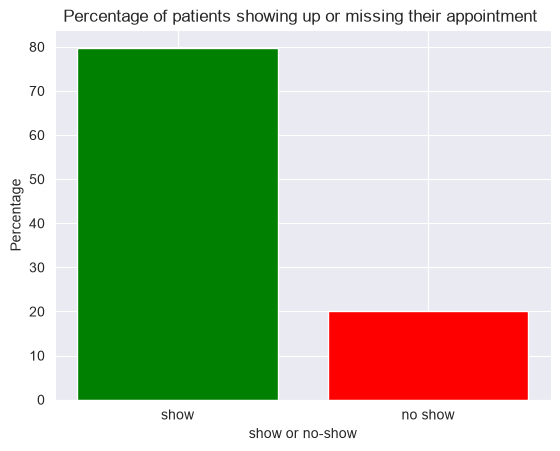

In [16]:
# percentage of show and no show
print(f"percentage of patients who didn't show up for their appointment is { (1-df.show.mean())*100 } %" )
no_show=len(df[df.show==0])/len(df.show)
show=len(df[df.show==1])/len(df.show)
plt.bar(['show','no show'],[show*100,no_show*100],color=['g','r']);
plt.title('Percentage of patients showing up or missing their appointment ');
plt.ylabel('Percentage');
plt.xlabel('show or no-show');
display(df.groupby('show')[['show']].count())

In [17]:
#create filters for show and no-show
show=(df.show == 1)
no_show=(df.show == 0)
total_miss=len(df[no_show])
total=len(df)

### <span style="color:DeepSkyBlue">b) Attendance by Gender</span> 


percentage of Females and Males who missed their appointment:


,count
gender,
F,13.204013
M,6.989242


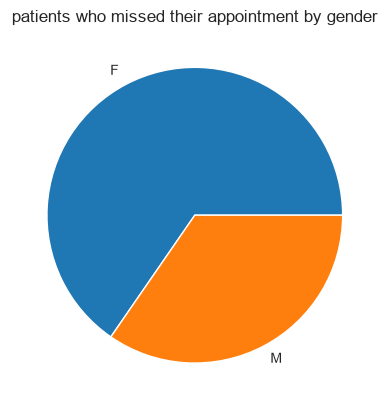

In [18]:
#get the number of patients missing their appointments by gender
no_show_gender=df[no_show]['gender'].value_counts()
no_show_gender.plot(kind='pie');
plt.title('patients who missed their appointment by gender');
print('percentage of Females and Males who missed their appointment:')
#get the percentage of patients missing their appointments by gender
pd.DataFrame(no_show_gender*100/total)

Text(0, 0.5, 'number of patients')

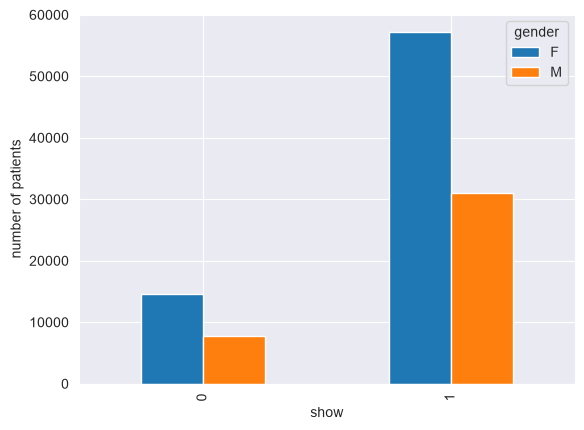

In [19]:
df.groupby(['gender','show']).size().unstack('gender').plot(kind='bar').set_ylabel('number of patients')

#### Finding 
#### The percentage of females missing their appointment is nearly two times the number of males. So females are more likely to miss their appointment.

### <span style="color:DeepSkyBlue">c) Scholarship and Appointment Attendance</span>


,show
scholarship,
0,0.801928
1,0.762637


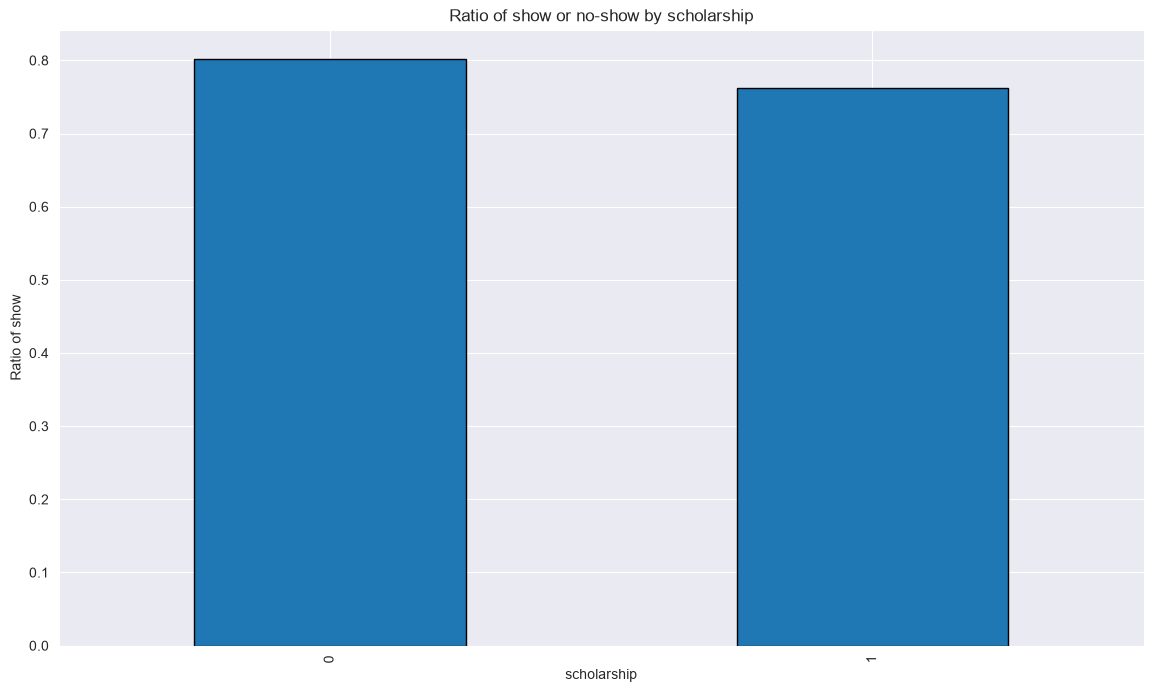

In [20]:
#what is the percentage of patients missing their appointment by scholarship
plot_rat(df.scholarship)
plt.title('Ratio of show or no-show by scholarship');
# df.groupby('scholarship')[['show']].mean()

#### Finding

#### It seems that patients with scholarships are actually more likely to miss their appointment


 ### <span style="color:DeepSkyBlue">d) Hypertension and Appointment Attendance </span>


,show
hipertension,
0,0.790963
1,0.826980


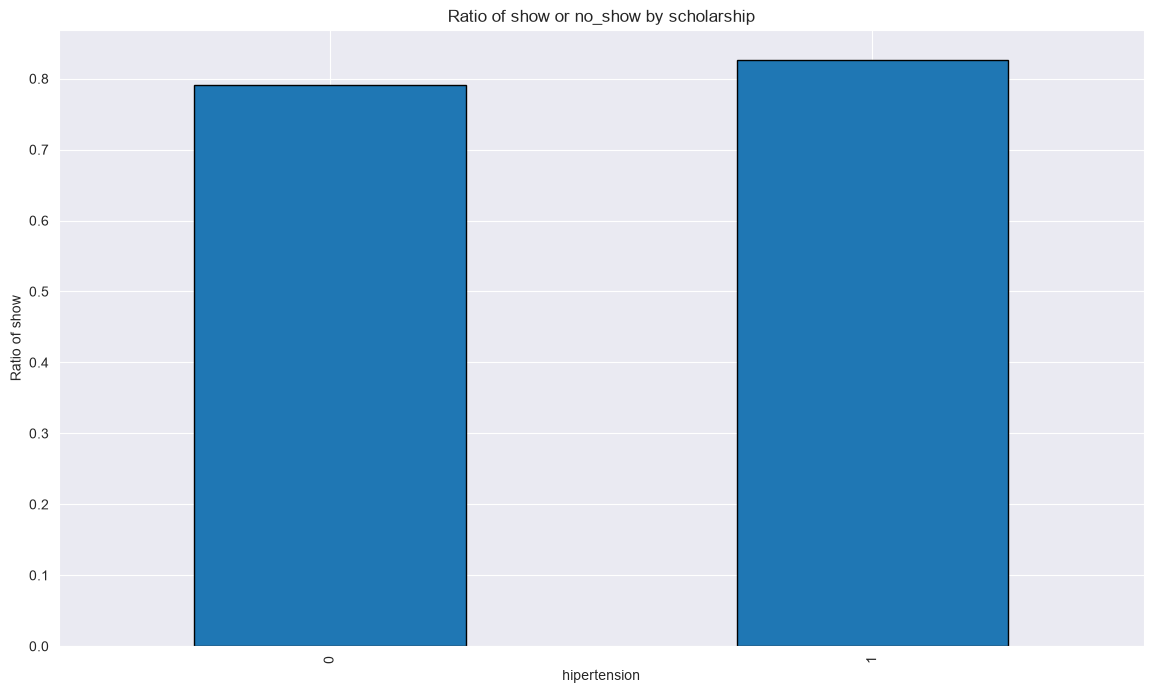

In [21]:
#what is the percentage of patients missing their appointment by hypertension
plot_rat(df.hipertension)
plt.title('Ratio of show or no_show by scholarship');

#### Finding

#### It seems that patients with hypertension are actually more likely to show up for their appointment


### <span style="color:DeepSkyBlue">e) SMS Reminders and Appointment Attendance</span>


,show
sms_received,
0,0.832967
1,0.724255


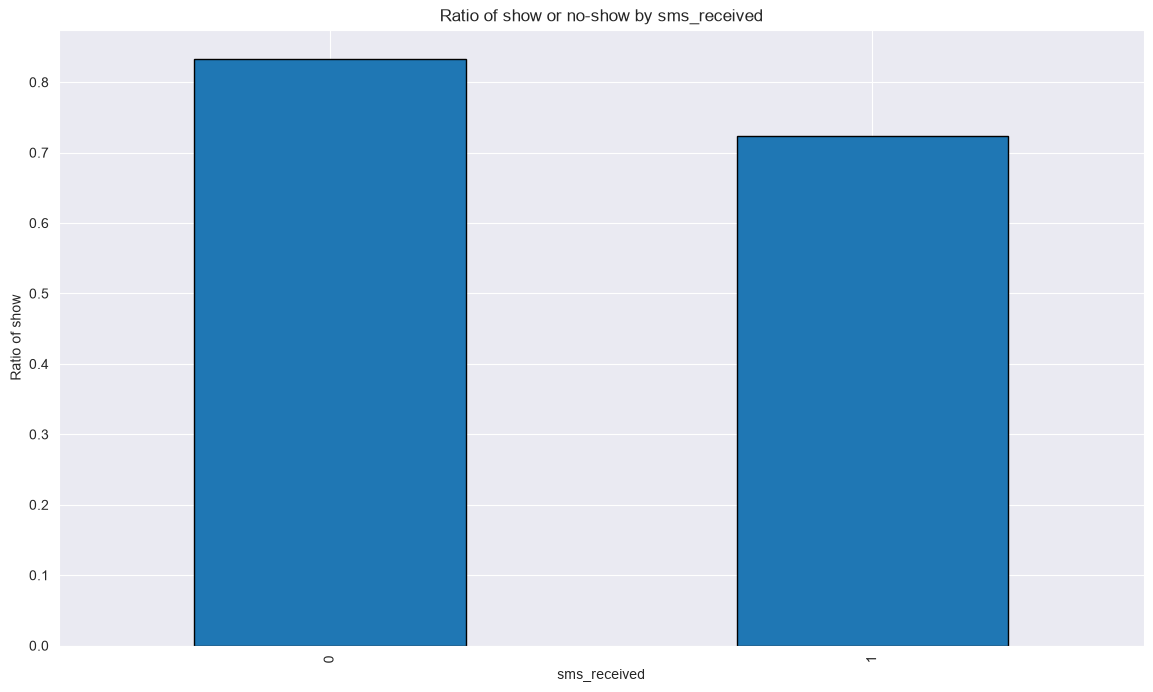

In [22]:
#what is the percentage of patient who attended their appointment by sms_received
plot_rat(df.sms_received)
plt.title('Ratio of show or no-show by sms_received');

#### Finding

#### A strange finding here suggests that patients who received an SMS are more likely to miss their appointment.


### <span style="color:DeepSkyBlue">f) Waiting Time and Appointment Attendance</span>


the propotion of different time difference for patients who missed their appiontments:


,count
day_diff2,
more_than_15,38.460505
more_than_4,32.922622
fewdays,20.565438
sameday,8.029034


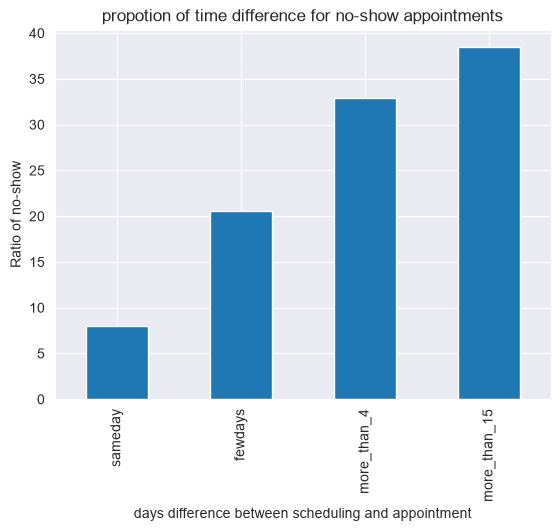

In [23]:
#filter for positive day difference
df1=df[df.day_diff>=0]
# df1.day_diff.unique()
#turn day diff into categorical column Day_diff2
bin_edges=[-1,0,4,15,179]
names=['sameday','fewdays','more_than_4','more_than_15']
df['day_diff2']=pd.cut(df1.day_diff,bin_edges,labels=names)
#filter for no-show records and count values for each category of day_diff2

no_show_day_diff=df[no_show].day_diff2.value_counts()/len(df[no_show])*100
no_show_day_diff.reindex(names).plot(kind='bar');
plt.title('propotion of time difference for no-show appointments');
plt.xlabel('days difference between scheduling and appointment');
plt.ylabel('Ratio of no-show');
print('the propotion of different time difference for patients who missed their appiontments:')
pd.DataFrame(no_show_day_diff)

#### Finding
It appears that the longer the period between the scheduling and appointment the more likely the patient won't show up.


### <span style="color:DeepSkyBlue">g) Age and Appointment Attendance</span>


,age
count,22319.000000
mean,34.317667
std,21.965941
min,0.000000
25%,16.000000
50%,33.000000
75%,51.000000
max,115.000000


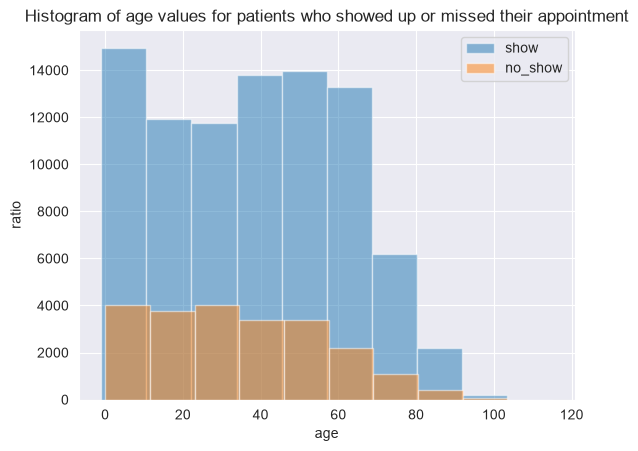

In [24]:
#plot the histograns of age for patients who showed up and who didn't
df[show].age.hist(alpha=0.5,label='show')
df[no_show].age.hist(alpha=0.5,label='no_show')
plt.legend()
plt.xlabel('age')
plt.ylabel('ratio')
plt.title('Histogram of age values for patients who showed up or missed their appointment')
#ger the mean age for patients who showed up and who didn't
df[no_show][['age']].describe()

#### Finding

#### There is no clear relation between the age and whether the patient shows up or not but younger patients are more likely to miss their appointments.




## <span style="color: tomato">5. Eda Conclusions</span>


#### After analyzing the dataset here are some findings:

1.  Percentage of patients who didn't show up for their appointment is 20.19%.
2.  The percentage of females missing their appointment is nearly two times the number of males. So females are more likely to miss their appointment.
3.  It appears that the longer the period between the scheduling and appointment the more likely the patient won't show up.
4.  It seems that patients with scholarships are actually more likely to miss their appointment.
5.  A strange finding here suggests that patients who received an SMS are more likely to miss their appointment !!
6.  There is no clear relation between the age and whether the patients show up or not but younger patients are more likely to miss their appointments.


## <span style="color: tomato">6. Predictive Modeling</span>


### <span style="color:DeepSkyBlue">a) Import Required Libraries</span>


In [26]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

### <span style="color:DeepSkyBlue">b) Prepare Data for Modeling</span>


In [27]:
# Remove invalid records found in this dataset (negative age, appointment before scheduling)
ml_df = df[(df['age'] >= 0) & (df['day_diff'] >= 0)].copy()

# Predict NO-SHOW as the positive class (1 = missed appointment),
# since that's the outcome a clinic actually wants to catch
ml_df['no_show'] = 1 - ml_df['show']

numeric_features = ['age', 'day_diff']
binary_features = ['scholarship', 'hipertension', 'diabetes',
                   'alcoholism', 'handcap', 'sms_received']
categorical_features = ['gender', 'neighbourhood']

X = ml_df[numeric_features + binary_features + categorical_features]
y = ml_df['no_show']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(88416, 10) (22105, 10)
no_show
0    0.798102
1    0.201898
Name: proportion, dtype: float64


### <span style="color:DeepSkyBlue">c) Build and Train the Logistic Regression Model</span>


In [28]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features),
], remainder='passthrough')  # binary columns pass through unchanged

model = Pipeline([
    ('prep', preprocessor),
    # class_weight='balanced' because only ~20% of patients are no-shows
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','day_diff','scholarship',...,'sms_received','gender', 'neighbourhood']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rema

### <span style="color:DeepSkyBlue">d) Evaluate the Model</span>


              precision    recall  f1-score   support

        Show       0.86      0.67      0.76     17642
     No-show       0.31      0.58      0.40      4463

    accuracy                           0.65     22105
   macro avg       0.59      0.62      0.58     22105
weighted avg       0.75      0.65      0.68     22105

ROC AUC: 0.665


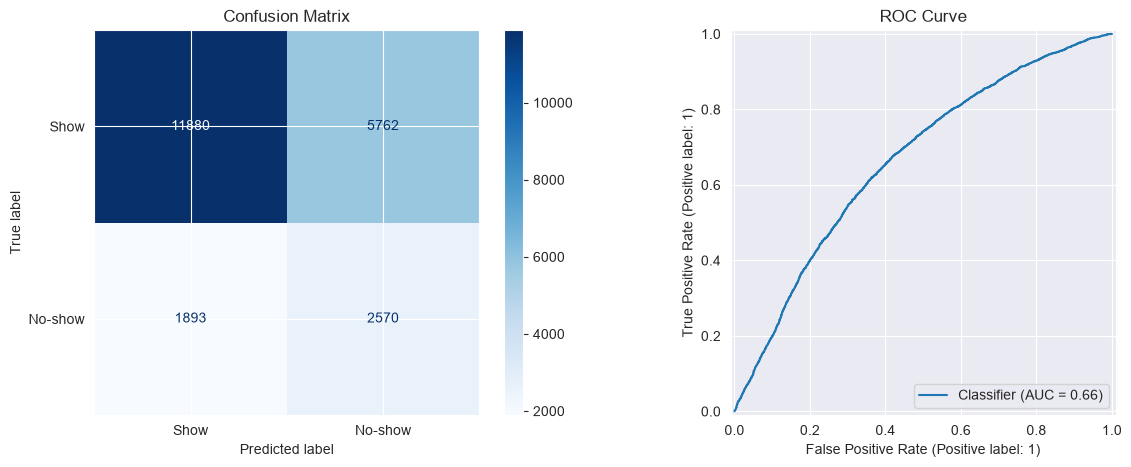

In [29]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Show', 'No-show']))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['Show', 'No-show']).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Confusion Matrix')
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
ax[1].set_title('ROC Curve')
plt.show()

### <span style="color:DeepSkyBlue">e) Cross-Validation</span>


In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print("CV ROC AUC:", scores.round(3), "| mean:", scores.mean().round(3))

c:\Users\DELL\OneDrive\Desktop\python\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


CV ROC AUC: [0.667 0.668 0.665 0.666 0.673] | mean: 0.668


### <span style="color:DeepSkyBlue">f) Interpret the Model Using Odds Ratios</span>


,feature,coef,odds_ratio
1,num__day_diff,0.456825,1.579052
88,remainder__sms_received,0.355360,1.426695
83,remainder__scholarship,0.186186,1.204646
86,remainder__alcoholism,0.152529,1.164777
85,remainder__diabetes,0.084163,1.087806
87,remainder__handcap,0.029872,1.030322
2,cat__gender_M,-0.023092,0.977173
84,remainder__hipertension,-0.078472,0.924528
0,num__age,-0.155310,0.856150


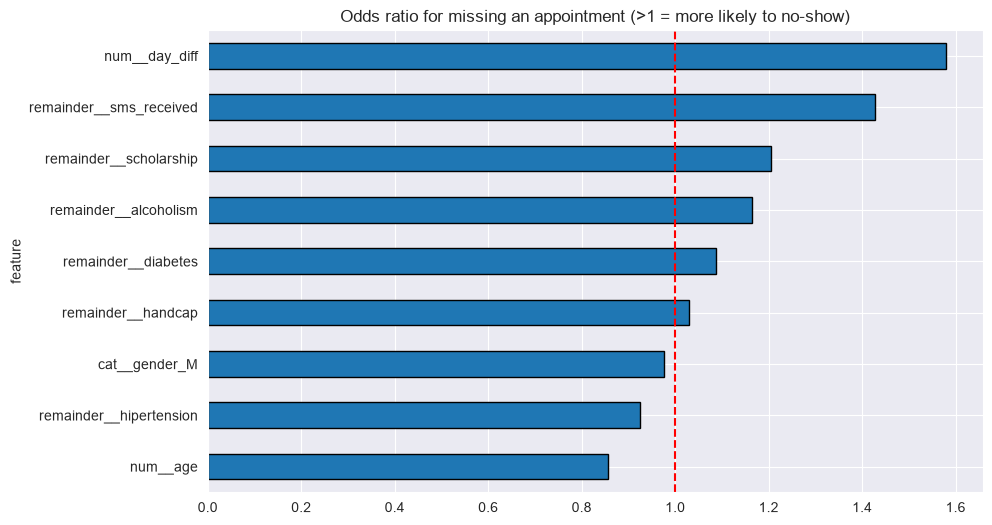

In [31]:
feature_names = model.named_steps['prep'].get_feature_names_out()
coefs = model.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['odds_ratio'] = np.exp(coef_df['coef'])
# Hide the many neighbourhood dummies for a readable view
main = coef_df[~coef_df['feature'].str.contains('neighbourhood')] \
          .sort_values('odds_ratio', ascending=False)
display(main)

main.set_index('feature')['odds_ratio'].sort_values().plot(
    kind='barh', figsize=(10, 6), edgecolor='black')
plt.axvline(1, color='red', linestyle='--')
plt.title('Odds ratio for missing an appointment (>1 = more likely to no-show)')
plt.show()

### <span style="color:DeepSkyBlue">g) Predict for a New Patient</span>


In [32]:
new_patient = pd.DataFrame([{
    'age': 25, 'day_diff': 20, 'scholarship': 1, 'hipertension': 0,
    'diabetes': 0, 'alcoholism': 0, 'handcap': 0, 'sms_received': 1,
    'gender': 'F', 'neighbourhood': 'JARDIM CAMBURI'
}])
print("Probability of no-show:", model.predict_proba(new_patient)[0, 1].round(3))

Probability of no-show: 0.609
